# **Analysing Company ESG performance - Data preparation **

## Objectives

This notebook documents the first part of this project. The overall goal for this project is to be use visualisations to explore the the ESG (Environmental, social and goverance) performance of global companies in 2022. The performance is based on the company's madaed disclosures to the New York Stock Exchange as well as ratings provided by third-party ratings agencies. We will be looking to see how performance is balanced across the three pillars.

To get our data ready for the visualisation stage of the project, the following steps are taken below:

- Setting up the project folder, working directly, virtual environment and other project requirements
- Importing the dataset from Kaggle as well as pandas, numpy, matplotlib and seaborn
- Initially exploring the dataset by looking for outliers, etc
- Identifying ways to clean and transform the dataset so that it is ready for analysis
- Exporting the cleaned dataset so that it can be imported into the visualisation notebook

## Inputs

The dataset for this project was downloaded from Kaggle: https://www.kaggle.com/datasets/alistairking/public-company-esg-ratings-dataset

I chose this dataset because it aligns currently with my existing role and the potential kinds of projects I will be using the data analysis skills I learn on this course for. As someone who is often involved in the creation of sustainability reports for companies in a variety of sectors, I have seen firsthand how company performance across the three ESG (Environmental, social and governance) pillars is often not uniform. For individual companies, there can be lots of reasons for this imbalance. For example, being able to accurately show carbon emissions reductions requires putting in place the processes needed to measure current emissions and set baselines. This can take a lot of time.

My aim for this project is to see whether there are any noticeable patterns or trends in how these ESG performance imbalances play out in this dataset.

## Outputs

The outputs for this notebook will be:

* An exported CSV file (public_company_esg_ratings_cleaned.csv) 

## Additional Comments

This first notebook only covers the data preparation stage of the project. The visualisation stage will be completed in a seperate notebook. This decision was made to enhance readability.




---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [2]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\chheb\\OneDrive\\Documents\\Programming\\Unit 1 Assessment - ESG Performance\\esg_corporate_analysis\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [4]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\chheb\\OneDrive\\Documents\\Programming\\Unit 1 Assessment - ESG Performance\\esg_corporate_analysis'

# Project setup

### Environment setup note

While installing project dependencies, `ppscore==1.1.0` consistently failed to build 
(`ModuleNotFoundError: No module named 'pkg_resources'`). After consulting AI, I tried two further options: upgrading `setuptools` and attempting the install with `--no-build-isolation`. Niether of these worked - meaning that I was not able to install the requirements.

Because the package's own documentation says it's not required post-analysis, and its purpose (predictive power scores as an alternative to standard correlation) is not essential to this project's methodology, I decided to remove it from `requirements.txt` (NOTE: it is commented out rather than fully deleted). Correlation between ESG pillar scores is instead assessed using pandas' `.corr()` alongside a seaborn heatmap.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/public_company_esg_ratings.csv")

## Initial exploration of the data

To start exploring the data, I used the the DISH method using the following methods and attribute:


- df.describe()
- df.info()
- df.shape
- df.head()

In [9]:
df.describe()

,environment_score,social_score,governance_score,total_score,cik
count,722.000000,722.000000,722.000000,722.000000,7.220000e+02
mean,404.806094,292.182825,278.761773,975.750693,9.897925e+05
std,145.103870,57.017406,47.031536,218.751796,5.816815e+05
min,200.000000,160.000000,75.000000,600.000000,1.800000e+03
25%,240.000000,243.000000,235.000000,763.000000,7.231572e+05
50%,483.000000,302.000000,300.000000,1046.000000,1.046189e+06
75%,518.750000,322.750000,310.000000,1144.000000,1.470094e+06
max,719.000000,667.000000,475.000000,1536.000000,1.914023e+06


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722 entries, 0 to 721
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ticker                722 non-null    object
 1   name                  722 non-null    object
 2   currency              722 non-null    object
 3   exchange              722 non-null    object
 4   industry              709 non-null    object
 5   logo                  702 non-null    object
 6   weburl                706 non-null    object
 7   environment_grade     722 non-null    object
 8   environment_level     722 non-null    object
 9   social_grade          722 non-null    object
 10  social_level          722 non-null    object
 11  governance_grade      722 non-null    object
 12  governance_level      722 non-null    object
 13  environment_score     722 non-null    int64 
 14  social_score          722 non-null    int64 
 15  governance_score      722 non-null    in

In [6]:
df.shape

(722, 21)

In [7]:
df.head()

,ticker,name,currency,exchange,industry,logo,weburl,environment_grade,environment_level,social_grade,...,governance_grade,governance_level,environment_score,social_score,governance_score,total_score,last_processing_date,total_grade,total_level,cik
0,dis,Walt Disney Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,https://static.finnhub.io/logo/ef50b4a2b263c84...,https://thewaltdisneycompany.com/,A,High,BB,...,BB,Medium,510,316,321,1147,19-04-2022,BBB,High,1744489
1,gm,General Motors Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Automobiles,https://static.finnhub.io/logo/9253db78-80c9-1...,https://www.gm.com/,A,High,BB,...,B,Medium,510,303,255,1068,17-04-2022,BBB,High,1467858
2,gww,WW Grainger Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Trading Companies and Distributors,https://static.finnhub.io/logo/f153dcda-80eb-1...,https://www.grainger.com/,B,Medium,BB,...,B,Medium,255,385,240,880,19-04-2022,BB,Medium,277135
3,mhk,Mohawk Industries Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Consumer products,https://static.finnhub.io/logo/26868a62-80ec-1...,https://mohawkind.com/,A,High,B,...,BB,Medium,570,298,303,1171,18-04-2022,BBB,High,851968
4,lyv,Live Nation Entertainment Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,https://static.finnhub.io/logo/1cd144d2-80ec-1...,https://www.livenationentertainment.com/,BBB,High,BB,...,B,Medium,492,310,250,1052,18-04-2022,BBB,High,1335258


## Initial observation 

Running .describe() on the dataset shows that the three ESG pillar scores are not measured on a consistent scale: 

- environment_score (mean ≈ 405, range 200-719)
- social_score (mean ≈ 292, range 160–667)
- governance_score (mean ≈ 279, range 75–475) 

This means that both social and governance are both notably lower and narrower in range. This needs to be addressed before analysis because comparing raw scores directly would make almost every company appear "Environment-heavy" by default. Before we can make any cross-pillar comparisons, the scores will need to be normalised onto a common scale (e.g. min-max scaling) so that imbalance reflects real differences in relative performance rather than differences in how each pillar happens to be scored.

## Looking for outliers

This [article] (https://pub.towardsai.net/a-practical-walkthrough-of-min-max-scaling-ee5c04ba5b6e) on min-max scaling says that any single extreme outlier will compress all the other “normal” data points into a very narrow range, losing a lot of the variance in the original data.

A box plot is the best way to quickly see if there are any extreme outliers in our data set.

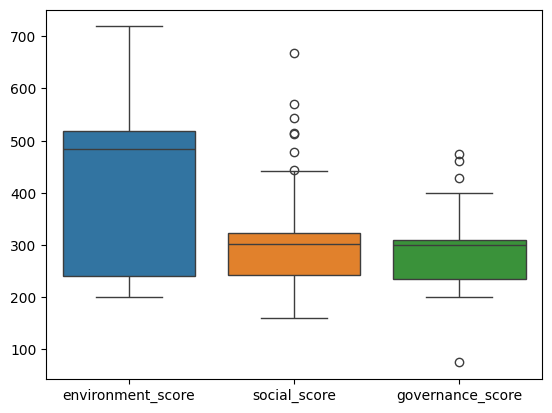

In [6]:
sns.boxplot(data=df[["environment_score", "social_score", "governance_score"]])
plt.show()

## Investigating outliers

The single low outlier for governance requires further investigation in order to determine whether it is a genuine outlier or data error. I start by filtering the data set to pull out all rows below 100. This will give me the name, sector and governance score. I then pulled the whole row to verfiy whether the other information we have about the company is consistent.

After looking at the data and investigating further online, I decide that CMS Energy's governance_score (75) is most likely a genuine, internally-consistent extreme value rather than a data error. It looks consistent when verified by cross-checking grade/level/score agreement.

It is also important to note that the information about the dataset on Kaggle does not say which third-party agency produced these ratings or their exact methodology. This is a limitation of the dataset, not just this one data point. 

In [5]:
gov_low_outlier = df[df['governance_score'] < 100][['name', 'industry', 'governance_score']]
gov_low_outlier

,name,industry,governance_score
457,CMS Energy Corp,Utilities,75


In [7]:
df.loc[457]

ticker                                                                cms
name                                                      CMS Energy Corp
currency                                                              USD
exchange                                    NEW YORK STOCK EXCHANGE, INC.
industry                                                        Utilities
logo                    https://static.finnhub.io/logo/a772ceae-80eb-1...
weburl                                         https://www.cmsenergy.com/
environment_grade                                                     BBB
environment_level                                                    High
social_grade                                                           AA
social_level                                                    Excellent
governance_grade                                                        C
governance_level                                                      Low
environment_score                     

I decide to repeat this process for the high outliers in both social and governance.

Filtering for governance scores of over 400 returns a small cluster of companies, all of which received a governance_grade of "BBB" and a governance_level of "High." I confirm this by using .unique() across the full dataset and seeing that no company received an "Excellent" governance level anywhere in the dataset. This suggests governance ratings in this dataset may have an effective ceiling below the top tier. I check the social and environment pillars and confirm this pattern is NOT repeated - both have instances of companies achieving "AA" grades and "excellent" levels. The lack of information about rating agency methodology makes it hard to judge whether this shows a trend refelcting company performance or the result of the rating criteria.

Filtering for social scores of over  450 returns several companies, all internally consistent between score, grade, and level. 

The most notable result is that CMS Energy (the same company identified earlier as the dataset's single low governance outlier) is also the highest-scoring company on Social. It is the only company in the entire dataset to receive an "AA" grade and "Excellent" level on the social pillar.

This seems to be a direct early example of a company can score exceptionally well on one ESG pillar while performing exceptionally poorly on another. 

In [8]:
gov_high_outlier = df[df['governance_score'] > 400][['name', 'industry', 'governance_score', 'governance_grade', 'governance_level']]
gov_high_outlier

,name,industry,governance_score,governance_grade,governance_level
112,Akoustis Technologies Inc,Electrical Equipment,428,BBB,High
137,Amazon.com Inc,Retail,460,BBB,High
253,Amphenol Corp,Electrical Equipment,475,BBB,High


In [9]:
social_high_outlier = df[df['social_score'] > 450][['name', 'industry', 'social_score', 'social_grade', 'social_level']]
social_high_outlier

,name,industry,social_score,social_grade,social_level
18,Airbnb Inc,Hotels Restaurants and Leisure,570,A,High
302,Edison International,Utilities,513,A,High
363,Pinnacle West Capital Corp,Utilities,479,BBB,High
452,Conocophillips,Energy,544,A,High
457,CMS Energy Corp,Utilities,667,AA,Excellent
564,Yelp Inc,Media,515,A,High


---

In [12]:

df['governance_level'].unique()

array(['Medium', 'High', 'Low'], dtype=object)

In [11]:
df['governance_grade'].unique()

array(['BB', 'B', 'BBB', 'C'], dtype=object)

In [14]:
df['environment_grade'].unique()

array(['A', 'B', 'BBB', 'BB', 'AA'], dtype=object)

In [15]:
df['environment_level'].unique()

array(['High', 'Medium', 'Excellent'], dtype=object)

In [16]:
df['social_level'].unique()

array(['Medium', 'High', 'Low', 'Excellent'], dtype=object)

In [18]:
df['social_grade'].unique()

array(['BB', 'B', 'A', 'BBB', 'CCC', 'AA'], dtype=object)

# Cleaning and preparing the data

To get the data ready for analysis, I took the following steps:

1. create df_clean = df.copy() so the raw dataframe stays available for comparison throughout.
2. Drop irrelevant/non-analytical columns by excluding cik, logo and weburl from analysis.
3. Check for duplicate rows — run .duplicated() on the full dataframe.
4. Check for duplicate companies specifically.
5. Check categorical consistency in industry — run .unique(), scan for near-duplicate labels and correct any inconsistencies (capitalisation, spacing, naming inconsistencies).
6. Handle missing values in industry — decide whether to drop those rows, leave them out of industry-level comparisons, or impute.
8. Decide on last_processing_date — is it needed for our analysis at all?
9. Re-run .info() and .isnull().sum() on the cleaned dataframe to confirm all planned changes were applied correctly.
10. Apply min-max normalisation to environment_score, social_score, governance_score to get the data ready for analysis and visualisation.

1. **Creating a new data frame**

In [7]:
df_clean = df.copy()

df_clean.head()

,ticker,name,currency,exchange,industry,logo,weburl,environment_grade,environment_level,social_grade,...,governance_grade,governance_level,environment_score,social_score,governance_score,total_score,last_processing_date,total_grade,total_level,cik
0,dis,Walt Disney Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,https://static.finnhub.io/logo/ef50b4a2b263c84...,https://thewaltdisneycompany.com/,A,High,BB,...,BB,Medium,510,316,321,1147,19-04-2022,BBB,High,1744489
1,gm,General Motors Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Automobiles,https://static.finnhub.io/logo/9253db78-80c9-1...,https://www.gm.com/,A,High,BB,...,B,Medium,510,303,255,1068,17-04-2022,BBB,High,1467858
2,gww,WW Grainger Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Trading Companies and Distributors,https://static.finnhub.io/logo/f153dcda-80eb-1...,https://www.grainger.com/,B,Medium,BB,...,B,Medium,255,385,240,880,19-04-2022,BB,Medium,277135
3,mhk,Mohawk Industries Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Consumer products,https://static.finnhub.io/logo/26868a62-80ec-1...,https://mohawkind.com/,A,High,B,...,BB,Medium,570,298,303,1171,18-04-2022,BBB,High,851968
4,lyv,Live Nation Entertainment Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,https://static.finnhub.io/logo/1cd144d2-80ec-1...,https://www.livenationentertainment.com/,BBB,High,BB,...,B,Medium,492,310,250,1052,18-04-2022,BBB,High,1335258


2. **Removing unnecessary columns**

In [8]:
df_clean['currency'].value_counts()

currency
USD    704
CNY     13
EUR      3
CHF      1
BRL      1
Name: count, dtype: int64

I was going to drop the "currency" column as well as the three below. But after checking, it is clear that my initial assumption that the only currency being listed was USD is false. Although the variance is low, this data may provide useful context for our analysis. I will therefore keep the currency column in df_clean. I have included a pie chart to give a visual representation of the how large the proportion of USD is compared to other currencies.

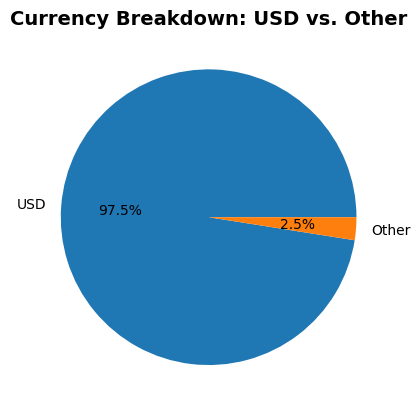

In [9]:
currency_counts = df['currency'].value_counts()

usd_count = currency_counts['USD']
other_count = currency_counts.drop('USD').sum()

currency_list = ['USD', 'Other']
currency_shares = [usd_count, other_count]

plt.pie(currency_shares, labels=currency_list, autopct='%1.1f%%')
plt.title('Currency Breakdown: USD vs. Other', fontsize=14, fontweight='bold')
plt.show()

In [10]:
df_clean = df_clean.drop(columns=['cik', 'weburl', 'logo'])

3. **Checking data frame for duplicates**

In [11]:
df_clean.duplicated().sum()

0

In [12]:
df_clean['ticker'].duplicated().sum()


0

In [13]:
df_clean['name'].duplicated().sum()

0

4. **Checking the consistency of industry labels**

In [14]:
df_clean['industry'].unique()

array(['Media', 'Automobiles', 'Trading Companies and Distributors',
       'Consumer products', 'Hotels Restaurants and Leisure',
       'Diversified Consumer Services', 'Airlines', 'Insurance',
       'Communications', 'Building', 'Technology', 'Electrical Equipment',
       'Logistics and Transportation', nan, 'Biotechnology',
       'Health Care', 'Life Sciences Tools and Services', 'Banking',
       'Semiconductors', 'Pharmaceuticals', 'Financial Services',
       'Commercial Services and Supplies', 'Chemicals', 'Real Estate',
       'Utilities', 'Machinery', 'Food Products', 'Retail', 'Energy',
       'Road and Rail', 'Distributors', 'Beverages', 'Telecommunication',
       'Professional Services', 'Auto Components', 'Packaging',
       'Aerospace and Defense', 'Tobacco', 'Metals and Mining',
       'Construction', 'Textiles Apparel and Luxury Goods',
       'Industrial Conglomerates', 'Leisure Products', 'Marine',
       'Hotels, Restaurants & Leisure', 'Metals & Mining', 'Energ

There are two issues with the industry list:

1. **Duplicates** 

Across the data, we can see a number of repeated industry labels with different spellings:

- 'Hotels Restaurants and Leisure' / 'Hotels, Restaurants & Leisure'
- 'Metals and Mining' / 'Metals & Mining'
- 'Aerospace and Defense' / 'Aerospace & Defense'
- 'Energy' / 'Energy '

These pairs should be merged in order to standardise the data.

2. **Closely related catergories**

There are also lots of catergories that conceptually overlap or are very closely related:

- 'Automobiles' and 'Auto Components' 
- 'Communications'/'Telecommunication'/'Media'
- 'Financial Services'/'Banking'
- 'Building'/'Construction'
- 'Trading Companies and Distributors'/'Distributors'

These should be left as they are - as merging them would be based on my own judgement rather than an objective need to clean the data

In [15]:
industry_corrections = {
    'Hotels, Restaurants & Leisure': 'Hotels Restaurants and Leisure',
    'Metals & Mining': 'Metals and Mining',
    'Aerospace & Defense': 'Aerospace and Defense',
    'Energy ': 'Energy'
}

df_clean['industry'] = df_clean['industry'].replace(industry_corrections)

df_clean['industry'].unique()

array(['Media', 'Automobiles', 'Trading Companies and Distributors',
       'Consumer products', 'Hotels Restaurants and Leisure',
       'Diversified Consumer Services', 'Airlines', 'Insurance',
       'Communications', 'Building', 'Technology', 'Electrical Equipment',
       'Logistics and Transportation', nan, 'Biotechnology',
       'Health Care', 'Life Sciences Tools and Services', 'Banking',
       'Semiconductors', 'Pharmaceuticals', 'Financial Services',
       'Commercial Services and Supplies', 'Chemicals', 'Real Estate',
       'Utilities', 'Machinery', 'Food Products', 'Retail', 'Energy',
       'Road and Rail', 'Distributors', 'Beverages', 'Telecommunication',
       'Professional Services', 'Auto Components', 'Packaging',
       'Aerospace and Defense', 'Tobacco', 'Metals and Mining',
       'Construction', 'Textiles Apparel and Luxury Goods',
       'Industrial Conglomerates', 'Leisure Products', 'Marine'],
      dtype=object)

5. **Deal with missing industry values**

The initial df.info() highlighted that there are 13 missing industry values. There are a few options for dealing with these:

- Remove them completely 
- change 'nan' to 'Unknown' 
- keep them as is but make sure to exclude them from industry-based analysis/visualisations

I initially considered dropping the data - but decided to relabel the values. Since comparisions between the ESG pillars is the principal focus of our analysis, labelling the missing values as 'Unknown' allows us to keep the pillar performance information. This will allow for richer comparisons across the pillars.

In [16]:
df_clean['industry'] = df_clean['industry'].fillna('Unknown')

df_clean['industry'].isnull().sum()



0

In [17]:
df_clean['industry'].value_counts()

industry
Technology                            63
Biotechnology                         56
Health Care                           51
Real Estate                           36
Financial Services                    33
Utilities                             30
Banking                               29
Electrical Equipment                  27
Insurance                             27
Retail                                26
Semiconductors                        24
Hotels Restaurants and Leisure        24
Media                                 23
Machinery                             21
Pharmaceuticals                       21
Energy                                21
Consumer products                     20
Chemicals                             19
Life Sciences Tools and Services      16
Food Products                         14
Unknown                               13
Aerospace and Defense                 11
Building                              10
Metals and Mining                     10
Textile

6. **Investigating and dropping 'last_processing_date' column**

I suspected that the range of dates in this column would be very closely grouped together because need to file thier disclosures by certain dealines. If true, I wouldn't need this column as it would not be adding anything useful to the analysis. 

I Converted 'last_processing_date' to a proper datetime type (originally stored as object/text) using pd.to_datetime(), then ran .describe() to check the spread of dates across the dataset.

The results showed most companies (approximately 75%, based on the 25th-75th percentile range) were processed within a fairly tight window between mid-April and mid-June 2022. However, the full range extends from 16 April 2022 to 15 November 2022. So a smaller subset of companies were rated up to seven months later than the majority. I have included a histogram to show this visually. (Note on the histogram: Because there were a lot of individual dates, showing a histogram with all the dates running along the x axis was very hard to read. I decided to group the dates by month instead. I used Claude as a guide for how to approach this.)

However, the core business question for this project is a cross-sectional comparison of ESG pillar performance rather than a time-series analysis. This column is not needed as an active variable for the planned analysis so I decided to drop it from df_clean.

This investigation is still worth noting as a limitation. Because the ratings were not all calculated at exactly the same point in time, it is possible that a company's underlying ESG conditions could have changed in the months between the earliest and latest processing dates in this dataset. I know from my job role that ratings agencies tend to work in annual review cycles - although many also have processes in place to adjust ratings based on unexpected events or significant policy changes. This is a small comparability concern worth flagging rather than ignoring, even though I don't think it warrants retaining the column itself.

In [18]:
df_clean['last_processing_date'] = pd.to_datetime(df_clean['last_processing_date'], format='%d-%m-%Y')
df_clean['last_processing_date'].describe()

count                              722
mean     2022-05-13 12:09:58.337950208
min                2022-04-16 00:00:00
25%                2022-04-17 00:00:00
50%                2022-04-18 00:00:00
75%                2022-06-10 00:00:00
max                2022-11-15 00:00:00
Name: last_processing_date, dtype: object

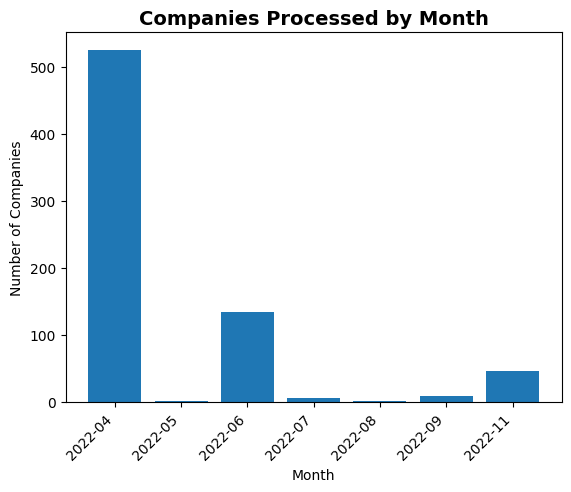

In [19]:
df['last_processing_date'] = pd.to_datetime(df['last_processing_date'], format='%d-%m-%Y')

df['processing_month'] = df['last_processing_date'].dt.to_period('M')

month_counts = df['processing_month'].value_counts().sort_index()

plt.bar(x=month_counts.index.astype(str), height=month_counts.values)
plt.title('Companies Processed by Month', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Month')
plt.ylabel('Number of Companies')
plt.show()

In [20]:
df_clean = df_clean.drop(columns=['last_processing_date'])


7. **Checking cleaned data frame**

In [11]:
df_clean.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722 entries, 0 to 721
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ticker             722 non-null    object
 1   name               722 non-null    object
 2   currency           722 non-null    object
 3   exchange           722 non-null    object
 4   industry           722 non-null    object
 5   environment_grade  722 non-null    object
 6   environment_level  722 non-null    object
 7   social_grade       722 non-null    object
 8   social_level       722 non-null    object
 9   governance_grade   722 non-null    object
 10  governance_level   722 non-null    object
 11  environment_score  722 non-null    int64 
 12  social_score       722 non-null    int64 
 13  governance_score   722 non-null    int64 
 14  total_score        722 non-null    int64 
 15  total_grade        722 non-null    object
 16  total_level        722 non-null    object
dt

In [12]:
df_clean.isnull().sum()

ticker               0
name                 0
currency             0
exchange             0
industry             0
environment_grade    0
environment_level    0
social_grade         0
social_level         0
governance_grade     0
governance_level     0
environment_score    0
social_score         0
governance_score     0
total_score          0
total_grade          0
total_level          0
dtype: int64

In [13]:
df_clean.head()

,ticker,name,currency,exchange,industry,environment_grade,environment_level,social_grade,social_level,governance_grade,governance_level,environment_score,social_score,governance_score,total_score,total_grade,total_level
0,dis,Walt Disney Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,A,High,BB,Medium,BB,Medium,510,316,321,1147,BBB,High
1,gm,General Motors Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Automobiles,A,High,BB,Medium,B,Medium,510,303,255,1068,BBB,High
2,gww,WW Grainger Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Trading Companies and Distributors,B,Medium,BB,Medium,B,Medium,255,385,240,880,BB,Medium
3,mhk,Mohawk Industries Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Consumer products,A,High,B,Medium,BB,Medium,570,298,303,1171,BBB,High
4,lyv,Live Nation Entertainment Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,BBB,High,BB,Medium,B,Medium,492,310,250,1052,BBB,High


In [14]:
df_clean.tail()

,ticker,name,currency,exchange,industry,environment_grade,environment_level,social_grade,social_level,governance_grade,governance_level,environment_score,social_score,governance_score,total_score,total_grade,total_level
717,hi,Hillenbrand Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Machinery,BBB,High,BB,Medium,BB,Medium,489,349,300,1138,BBB,High
718,hhc,Howard Hughes Corp,USD,"NEW YORK STOCK EXCHANGE, INC.",Real Estate,A,High,BB,Medium,BB,Medium,500,300,300,1100,BBB,High
719,hubs,HubSpot Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Technology,BBB,High,BB,Medium,BB,Medium,480,329,320,1129,BBB,High
720,hesm,Hess Midstream LP,USD,"NEW YORK STOCK EXCHANGE, INC.",Energy,BB,Medium,B,Medium,B,Medium,307,257,255,819,BB,Medium
721,hei,HEICO Corp,USD,"NEW YORK STOCK EXCHANGE, INC.",Aerospace and Defense,B,Medium,B,Medium,B,Medium,225,203,205,633,B,Medium


## Summary of data cleaning and preparation

- The dataset began with 722 rows and 21 columns. After cleaning, the working dataset (df_clean) retains all 722 rows and 17 columns. No rows were removed.

Columns dropped (4 total):

- cik: a unique identifier used by the SEC and not useful for ESG analysis.
- logo, weburl: presentational metadata (image/website links) with no analytical value.
- last_processing_date: investigated for potential comparability concerns. Not needed for cross-sectional analysis so dropped.

Columns modified:

- industry: 40 unique categories were reduced after identifying and merging four sets of inconsistent labels representing the same industry. Genuinely distinct-but-related categories (e.g. "Banking" vs "Financial Services") were deliberately left unmerged, to avoid overriding the dataset's own classification with subjective judgement.
- industry missing values: 13 companies had no industry listed. Rather than dropping these rows and losing valid ESG score data, the missing values were changed to "Unknown" to preserve the data while keeping it distinct.

Columns investigated but retained:

- currency: while 704 of 722 companies report in USD, a minority use CNY, EUR, CHF, or BRL. The column was kep as this is potentially relevant context.

Data quality checks performed:

- Confirmed zero duplicate rows, and zero duplicate values in both ticker and name, ruling out double-counted companies.
- Confirmed last_processing_date spread: most companies (~75%) were rated within a two-month window, though a minority were processed up to seven months later. This was flagged as a minor comparability limitation but the column was dropped.

Outcome: 

The clean dataset is free of duplicates, has consistent industry labelling, contains no null values across any column and retains all original companies for analysis. 

The next step is min-max normalisation of the three ESG pillar scores, required before any cross-pillar comparison can be made.

---

# Min-max normalisation of the ESG pillars #

During the initial investigation, I saw that environment_score, social_score, and governance_score are measured on different underlying scales (e.g. environment_score ranges 200–719, while governance_score ranges 75–475). This meant raw scores could not be directly compared without distorting any conclusions about pillar imbalance. Since comparing the performance across pillars is the main focus of my investigation, I decided to address this using min-max normalisation to rescale all three pillar scores onto a common 0–1 range. I used the standard formula:

scaled_value = (x − min) / (max − min)

I tested on a single column (environment_score) first to confirm the logic worked correctly before applying it to the other pillars. I created a new column alongside the original raw score instead of overwriting it so that I could compare both versions directly. 

Once I knew the approach worked, I created a reusable function. This way I didn't have to repeat the same formula for each of the three pillar columns individually and any future correction to the formula only needs to be made once.

The function was then applied to all three pillar scores. The Output was rounded to two decimal places for readability.

In [21]:
df_clean["environment_score_norm"] = (df_clean["environment_score"] - df_clean["environment_score"].min()) / (df_clean["environment_score"].max() - df_clean["environment_score"].min())

df_clean[["environment_score", "environment_score_norm"]].head()

,environment_score,environment_score_norm
0,510,0.597303
1,510,0.597303
2,255,0.105973
3,570,0.712909
4,492,0.562620


In [23]:
def min_max_normalise(df, column):
    normalised = (df[column] - df[column].min()) / (df[column].max() - df[column].min())
    return normalised.round(2)

df_clean["environment_score_norm"] = min_max_normalise(df_clean, "environment_score")
df_clean["social_score_norm"] = min_max_normalise(df_clean, "social_score")
df_clean["governance_score_norm"] = min_max_normalise(df_clean, "governance_score")

df_clean.head()

,ticker,name,currency,exchange,industry,environment_grade,environment_level,social_grade,social_level,governance_grade,governance_level,environment_score,social_score,governance_score,total_score,total_grade,total_level,environment_score_norm,social_score_norm,governance_score_norm
0,dis,Walt Disney Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,A,High,BB,Medium,BB,Medium,510,316,321,1147,BBB,High,0.60,0.31,0.62
1,gm,General Motors Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Automobiles,A,High,BB,Medium,B,Medium,510,303,255,1068,BBB,High,0.60,0.28,0.45
2,gww,WW Grainger Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Trading Companies and Distributors,B,Medium,BB,Medium,B,Medium,255,385,240,880,BB,Medium,0.11,0.44,0.41
3,mhk,Mohawk Industries Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Consumer products,A,High,B,Medium,BB,Medium,570,298,303,1171,BBB,High,0.71,0.27,0.57
4,lyv,Live Nation Entertainment Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,BBB,High,BB,Medium,B,Medium,492,310,250,1052,BBB,High,0.56,0.30,0.44


---

# Exporting df_clean

The visualisation part of this project will be done in a seperate notebook as this one is long enough already. For that reason, I will export the cleaned dataset as a csv file. This can then be imported directly into the new notebook to create visualisations.

In [24]:
df_clean.to_csv("data/public_company_esg_ratings_cleaned.csv", index=False)
